BASE TEST - WS30

Argmax caleb

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    recall_score, f1_score, accuracy_score,
    precision_score, confusion_matrix
)

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS30.csv" # Updated to your new dataset name
RANDOM_SEED  = 42

# Class Mapping and Imbalance Weights
CLASS_MAP    = {"NB": 0, "BH": 1, "DB": 2}
CLASSES      = [0, 1, 2]
# Heavily weight minority classes (BH and DB) vs majority (NB)
CLASS_WEIGHTS = {0: 1, 1: 20, 2: 20} 

# ─────────────────────────────────────────────────────────────────────────────
# ❷  FEATURE DEFINITIONS (Updated: Removed dead LF features)
# ─────────────────────────────────────────────────────────────────────────────
# Removed "LF" and "LF_HF_Ratio" from the base list
RAW_FEATURES = [
    "Mean_RR", "SDNN", "RMSSD", "pNN50", "CV_RR", "HF", 
    "EDR_Mean_Amp", "EDR_Std_Amp", "EDR_Peak_to_Peak",
    "Shannon_Entropy"
]

# Removed explicit addition of ["Raw_LF_HF_Ratio"]
G_LIST = (
    [f"{f}_Delta" for f in RAW_FEATURES] +   
    [f"{f}_Ratio" for f in RAW_FEATURES]    
)

# This will result in exactly 20 active features being passed to the model

# ═══════════════════════════════════════════════════════════════════════════════
# LOSO EVALUATION (Leave-One-Subject-Out)
# ═══════════════════════════════════════════════════════════════════════════════

def run_loso(df):
    """
    Leave-One-Subject-Out cross-validation for Multi-Class (NB, BH, DB).
    """
    print("\n" + "=" * 90)
    print("LOSO EVALUATION: MULTI-CLASS (NB, BH, DB)")
    print("=" * 90)

    # Encode categories into integers
    df["y"] = df["Category"].map(CLASS_MAP)
    subjects = sorted(df["Subject"].unique())

    all_y_true, all_y_prob, all_y_pred = [], [], []

    # Header for metrics
    header = (f"  {'Sub':6s} | {'N_NB':>4} | {'N_BH':>4} | {'N_DB':>4} | "
              f"{'Acc':>5} | {'Mac_Prec':>8} | {'Mac_Rec':>7} | {'Mac_F1':>6}")
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:
        tr_mask = df["Subject"] != test_sub
        te_mask = df["Subject"] == test_sub

        # ── 1. Train on ALL OTHER Subjects ──────────────────────────────────
        X_tr = df.loc[tr_mask, G_LIST].fillna(0).values
        y_tr = df.loc[tr_mask, "y"].values

        base_rf = RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight=CLASS_WEIGHTS,
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
        # Isotonic calibration applied to multi-class (One-vs-Rest internally)
        clf = CalibratedClassifierCV(base_rf, method="isotonic", cv=3)
        clf.fit(X_tr, y_tr)

        # ── 2. Evaluate on Held-Out Subject ─────────────────────────────────
        X_eval = df.loc[te_mask, G_LIST].fillna(0).values
        y_eval = df.loc[te_mask, "y"].values

        if len(y_eval) == 0:
            continue

        # predict_proba returns shape (N, 3) for the 3 classes
        eval_prob = clf.predict_proba(X_eval)
        # Select the class with the highest probability
        eval_pred = np.argmax(eval_prob, axis=1)

        all_y_true.extend(y_eval.tolist())
        all_y_prob.extend(eval_prob.tolist())
        all_y_pred.extend(eval_pred.tolist())

        # Subject-level metrics (Macro average for multi-class)
        acc  = accuracy_score(y_eval, eval_pred)
        prec = precision_score(y_eval, eval_pred, average='macro', zero_division=0)
        rec  = recall_score(y_eval, eval_pred, average='macro', zero_division=0)
        f1   = f1_score(y_eval, eval_pred, average='macro', zero_division=0)
        
        n_nb = (y_eval == 0).sum()
        n_bh = (y_eval == 1).sum()
        n_db = (y_eval == 2).sum()

        print(f"  {test_sub:6s} | {n_nb:>4} | {n_bh:>4} | {n_db:>4} | "
              f"{acc:>5.3f} | {prec:>8.3f} | {rec:>7.3f} | {f1:>6.3f}")

    # ── Aggregate Results ───────────────────────────────────────────────────
    if len(all_y_true) == 0:
        print("\n  [!] No valid evaluation windows found across subjects.")
        return

    yt = np.array(all_y_true)
    yp = np.array(all_y_prob)
    yd = np.array(all_y_pred)

    # ── ONE HOT ENCODING FOR METRICS ──
    # AUROC & AUPRC require the true labels to be One-Hot Encoded in multi-class
    yt_ohe = label_binarize(yt, classes=CLASSES)

    # Calculate overall metrics using macro-averaging
    auroc = roc_auc_score(yt_ohe, yp, multi_class='ovr', average='macro')
    # Use weights for AUPRC to account for class imbalance
    auprc = average_precision_score(yt_ohe, yp, average='macro')
    
    acc   = accuracy_score(yt, yd)
    prec  = precision_score(yt, yd, average='macro', zero_division=0)
    rec   = recall_score(yt, yd, average='macro', zero_division=0)
    f1    = f1_score(yt, yd, average='macro', zero_division=0)
    
    cm = confusion_matrix(yt, yd, labels=CLASSES)

    print("\n  " + "─" * 65)
    print(f"  ── CALIBRATED LOSO OVERALL (MACRO AVERAGED) ──")
    print(f"     AUROC (OVR) = {auroc:.4f}")
    print(f"     AUPRC       = {auprc:.4f}")
    print(f"     Accuracy    = {acc:.3f}")
    print(f"     Recall      = {rec:.3f}")
    print(f"     Precision   = {prec:.3f}")
    print(f"     F1 Score    = {f1:.3f}")
    
    print("\n     ── OVERALL CONFUSION MATRIX ──")
    print(f"                 Pred NB (0)   Pred BH (1)   Pred DB (2)")
    print(f"   Actual NB (0) {cm[0,0]:<13} {cm[0,1]:<13} {cm[0,2]:<13}")
    print(f"   Actual BH (1) {cm[1,0]:<13} {cm[1,1]:<13} {cm[1,2]:<13}")
    print(f"   Actual DB (2) {cm[2,0]:<13} {cm[2,1]:<13} {cm[2,2]:<13}")
    print("  " + "─" * 65)


# ═══════════════════════════════════════════════════════════════════════════════
# ENTRY POINT
# ═══════════════════════════════════════════════════════════════════════════════

def main():
    np.random.seed(RANDOM_SEED)

    if not os.path.exists(INPUT_CSV):
        print(f"\n[!] ERROR: {INPUT_CSV} not found. Please run your feature extraction script first.")
        return

    print(f"Loading {INPUT_CSV} ...")
    df = pd.read_csv(INPUT_CSV)
    
    # Ensure all required features are present
    missing = [f for f in G_LIST if f not in df.columns]
    if missing:
        print(f"\n[!] ERROR: Missing features in CSV: {missing}")
        return
        
    if "Category" not in df.columns:
        print("\n[!] ERROR: 'Category' column missing from data.")
        return

    print(f"\nDataset Overview: {len(df):,} total windows")
    for cat in CLASS_MAP.keys():
        count = (df['Category'] == cat).sum()
        print(f"  {cat} = {count:,}")
    print(f"  Subjects = {df['Subject'].nunique()}")

    # Run the evaluation
    run_loso(df)

if __name__ == "__main__":
    main()

Loading BH_DB_Features_WS30.csv ...

Dataset Overview: 25,290 total windows
  NB = 18,116
  BH = 2,252
  DB = 4,922
  Subjects = 41

LOSO EVALUATION: MULTI-CLASS (NB, BH, DB)
  Sub    | N_NB | N_BH | N_DB |   Acc | Mac_Prec | Mac_Rec | Mac_F1
  ─────────────────────────────────────────────────────────────────
  S_10   |  389 |    0 |  115 | 0.885 |    0.618 |   0.550 |  0.581
  S_11   |  417 |   60 |  112 | 0.874 |    0.819 |   0.832 |  0.816
  S_14   |  407 |   60 |  129 | 0.822 |    0.822 |   0.718 |  0.757
  S_15   |  432 |   60 |  114 | 0.949 |    0.935 |   0.936 |  0.932
  S_16   |  403 |   60 |  126 | 0.902 |    0.932 |   0.859 |  0.883
  S_18   |  407 |   43 |  122 | 0.857 |    0.893 |   0.595 |  0.598
  S_19   |  372 |   60 |  129 | 0.847 |    0.885 |   0.672 |  0.728
  S_20   |  409 |   31 |  121 | 0.870 |    0.799 |   0.780 |  0.787
  S_21   |  434 |   60 |  111 | 0.873 |    0.880 |   0.772 |  0.817
  S_22   |  433 |   60 |  111 | 0.909 |    0.913 |   0.781 |  0.804
  S_23   

BASE TEST - WS20

Argmax caleb

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    recall_score, f1_score, accuracy_score,
    precision_score, confusion_matrix
)

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS20.csv" # Updated to your new dataset name
RANDOM_SEED  = 42

# Class Mapping and Imbalance Weights
CLASS_MAP    = {"NB": 0, "BH": 1, "DB": 2}
CLASSES      = [0, 1, 2]
# Heavily weight minority classes (BH and DB) vs majority (NB)
CLASS_WEIGHTS = {0: 1, 1: 20, 2: 20} 

# ─────────────────────────────────────────────────────────────────────────────
# ❷  FEATURE DEFINITIONS (Updated: Removed dead LF features)
# ─────────────────────────────────────────────────────────────────────────────
# Removed "LF" and "LF_HF_Ratio" from the base list
RAW_FEATURES = [
    "Mean_RR", "SDNN", "RMSSD", "pNN50", "CV_RR", "HF", 
    "EDR_Mean_Amp", "EDR_Std_Amp", "EDR_Peak_to_Peak",
    "Shannon_Entropy"
]

# Removed explicit addition of ["Raw_LF_HF_Ratio"]
G_LIST = (
    [f"{f}_Delta" for f in RAW_FEATURES] +   
    [f"{f}_Ratio" for f in RAW_FEATURES]    
)

# This will result in exactly 20 active features being passed to the model

# ═══════════════════════════════════════════════════════════════════════════════
# LOSO EVALUATION (Leave-One-Subject-Out)
# ═══════════════════════════════════════════════════════════════════════════════

def run_loso(df):
    """
    Leave-One-Subject-Out cross-validation for Multi-Class (NB, BH, DB).
    """
    print("\n" + "=" * 90)
    print("LOSO EVALUATION: MULTI-CLASS (NB, BH, DB)")
    print("=" * 90)

    # Encode categories into integers
    df["y"] = df["Category"].map(CLASS_MAP)
    subjects = sorted(df["Subject"].unique())

    all_y_true, all_y_prob, all_y_pred = [], [], []

    # Header for metrics
    header = (f"  {'Sub':6s} | {'N_NB':>4} | {'N_BH':>4} | {'N_DB':>4} | "
              f"{'Acc':>5} | {'Mac_Prec':>8} | {'Mac_Rec':>7} | {'Mac_F1':>6}")
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:
        tr_mask = df["Subject"] != test_sub
        te_mask = df["Subject"] == test_sub

        # ── 1. Train on ALL OTHER Subjects ──────────────────────────────────
        X_tr = df.loc[tr_mask, G_LIST].fillna(0).values
        y_tr = df.loc[tr_mask, "y"].values

        base_rf = RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight=CLASS_WEIGHTS,
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
        # Isotonic calibration applied to multi-class (One-vs-Rest internally)
        clf = CalibratedClassifierCV(base_rf, method="isotonic", cv=3)
        clf.fit(X_tr, y_tr)

        # ── 2. Evaluate on Held-Out Subject ─────────────────────────────────
        X_eval = df.loc[te_mask, G_LIST].fillna(0).values
        y_eval = df.loc[te_mask, "y"].values

        if len(y_eval) == 0:
            continue

        # predict_proba returns shape (N, 3) for the 3 classes
        eval_prob = clf.predict_proba(X_eval)
        # Select the class with the highest probability
        eval_pred = np.argmax(eval_prob, axis=1)

        all_y_true.extend(y_eval.tolist())
        all_y_prob.extend(eval_prob.tolist())
        all_y_pred.extend(eval_pred.tolist())

        # Subject-level metrics (Macro average for multi-class)
        acc  = accuracy_score(y_eval, eval_pred)
        prec = precision_score(y_eval, eval_pred, average='macro', zero_division=0)
        rec  = recall_score(y_eval, eval_pred, average='macro', zero_division=0)
        f1   = f1_score(y_eval, eval_pred, average='macro', zero_division=0)
        
        n_nb = (y_eval == 0).sum()
        n_bh = (y_eval == 1).sum()
        n_db = (y_eval == 2).sum()

        print(f"  {test_sub:6s} | {n_nb:>4} | {n_bh:>4} | {n_db:>4} | "
              f"{acc:>5.3f} | {prec:>8.3f} | {rec:>7.3f} | {f1:>6.3f}")

    # ── Aggregate Results ───────────────────────────────────────────────────
    if len(all_y_true) == 0:
        print("\n  [!] No valid evaluation windows found across subjects.")
        return

    yt = np.array(all_y_true)
    yp = np.array(all_y_prob)
    yd = np.array(all_y_pred)

    # ── ONE HOT ENCODING FOR METRICS ──
    # AUROC & AUPRC require the true labels to be One-Hot Encoded in multi-class
    yt_ohe = label_binarize(yt, classes=CLASSES)

    # Calculate overall metrics using macro-averaging
    auroc = roc_auc_score(yt_ohe, yp, multi_class='ovr', average='macro')
    # Use weights for AUPRC to account for class imbalance
    auprc = average_precision_score(yt_ohe, yp, average='macro')
    
    acc   = accuracy_score(yt, yd)
    prec  = precision_score(yt, yd, average='macro', zero_division=0)
    rec   = recall_score(yt, yd, average='macro', zero_division=0)
    f1    = f1_score(yt, yd, average='macro', zero_division=0)
    
    cm = confusion_matrix(yt, yd, labels=CLASSES)

    print("\n  " + "─" * 65)
    print(f"  ── CALIBRATED LOSO OVERALL (MACRO AVERAGED) ──")
    print(f"     AUROC (OVR) = {auroc:.4f}")
    print(f"     AUPRC       = {auprc:.4f}")
    print(f"     Accuracy    = {acc:.3f}")
    print(f"     Recall      = {rec:.3f}")
    print(f"     Precision   = {prec:.3f}")
    print(f"     F1 Score    = {f1:.3f}")
    
    print("\n     ── OVERALL CONFUSION MATRIX ──")
    print(f"                 Pred NB (0)   Pred BH (1)   Pred DB (2)")
    print(f"   Actual NB (0) {cm[0,0]:<13} {cm[0,1]:<13} {cm[0,2]:<13}")
    print(f"   Actual BH (1) {cm[1,0]:<13} {cm[1,1]:<13} {cm[1,2]:<13}")
    print(f"   Actual DB (2) {cm[2,0]:<13} {cm[2,1]:<13} {cm[2,2]:<13}")
    print("  " + "─" * 65)


# ═══════════════════════════════════════════════════════════════════════════════
# ENTRY POINT
# ═══════════════════════════════════════════════════════════════════════════════

def main():
    np.random.seed(RANDOM_SEED)

    if not os.path.exists(INPUT_CSV):
        print(f"\n[!] ERROR: {INPUT_CSV} not found. Please run your feature extraction script first.")
        return

    print(f"Loading {INPUT_CSV} ...")
    df = pd.read_csv(INPUT_CSV)
    
    # Ensure all required features are present
    missing = [f for f in G_LIST if f not in df.columns]
    if missing:
        print(f"\n[!] ERROR: Missing features in CSV: {missing}")
        return
        
    if "Category" not in df.columns:
        print("\n[!] ERROR: 'Category' column missing from data.")
        return

    print(f"\nDataset Overview: {len(df):,} total windows")
    for cat in CLASS_MAP.keys():
        count = (df['Category'] == cat).sum()
        print(f"  {cat} = {count:,}")
    print(f"  Subjects = {df['Subject'].nunique()}")

    # Run the evaluation
    run_loso(df)

if __name__ == "__main__":
    main()

Loading BH_DB_Features_WS20.csv ...

Dataset Overview: 28,090 total windows
  NB = 21,529
  BH = 3,505
  DB = 3,056
  Subjects = 41

LOSO EVALUATION: MULTI-CLASS (NB, BH, DB)
  Sub    | N_NB | N_BH | N_DB |   Acc | Mac_Prec | Mac_Rec | Mac_F1
  ─────────────────────────────────────────────────────────────────
  S_10   |  469 |   40 |   75 | 0.918 |    0.789 |   0.830 |  0.802
  S_11   |  497 |   90 |   72 | 0.917 |    0.867 |   0.827 |  0.841
  S_14   |  497 |   90 |   79 | 0.865 |    0.770 |   0.715 |  0.740
  S_15   |  512 |   90 |   71 | 0.951 |    0.910 |   0.930 |  0.915
  S_16   |  493 |   90 |   76 | 0.944 |    0.926 |   0.893 |  0.907
  S_18   |  487 |   76 |   80 | 0.837 |    0.642 |   0.599 |  0.589
  S_19   |  456 |   90 |   81 | 0.856 |    0.869 |   0.700 |  0.725
  S_20   |  492 |   65 |   72 | 0.884 |    0.788 |   0.692 |  0.730
  S_21   |  514 |   90 |   71 | 0.910 |    0.898 |   0.786 |  0.832
  S_22   |  513 |   90 |   66 | 0.880 |    0.869 |   0.735 |  0.756
  S_23   

BASE TEST - WS15

Argmax caleb

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    recall_score, f1_score, accuracy_score,
    precision_score, confusion_matrix
)

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS15.csv" # Updated to your new dataset name
RANDOM_SEED  = 42

# Class Mapping and Imbalance Weights
CLASS_MAP    = {"NB": 0, "BH": 1, "DB": 2}
CLASSES      = [0, 1, 2]
# Heavily weight minority classes (BH and DB) vs majority (NB)
CLASS_WEIGHTS = {0: 1, 1: 20, 2: 20} 

# ─────────────────────────────────────────────────────────────────────────────
# ❷  FEATURE DEFINITIONS (Updated: Removed dead LF features)
# ─────────────────────────────────────────────────────────────────────────────
# Removed "LF" and "LF_HF_Ratio" from the base list
RAW_FEATURES = [
    "Mean_RR", "SDNN", "RMSSD", "pNN50", "CV_RR", "HF", 
    "EDR_Mean_Amp", "EDR_Std_Amp", "EDR_Peak_to_Peak",
    "Shannon_Entropy"
]

# Removed explicit addition of ["Raw_LF_HF_Ratio"]
G_LIST = (
    [f"{f}_Delta" for f in RAW_FEATURES] +   
    [f"{f}_Ratio" for f in RAW_FEATURES]    
)

# This will result in exactly 20 active features being passed to the model

# ═══════════════════════════════════════════════════════════════════════════════
# LOSO EVALUATION (Leave-One-Subject-Out)
# ═══════════════════════════════════════════════════════════════════════════════

def run_loso(df):
    """
    Leave-One-Subject-Out cross-validation for Multi-Class (NB, BH, DB).
    """
    print("\n" + "=" * 90)
    print("LOSO EVALUATION: MULTI-CLASS (NB, BH, DB)")
    print("=" * 90)

    # Encode categories into integers
    df["y"] = df["Category"].map(CLASS_MAP)
    subjects = sorted(df["Subject"].unique())

    all_y_true, all_y_prob, all_y_pred = [], [], []

    # Header for metrics
    header = (f"  {'Sub':6s} | {'N_NB':>4} | {'N_BH':>4} | {'N_DB':>4} | "
              f"{'Acc':>5} | {'Mac_Prec':>8} | {'Mac_Rec':>7} | {'Mac_F1':>6}")
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:
        tr_mask = df["Subject"] != test_sub
        te_mask = df["Subject"] == test_sub

        # ── 1. Train on ALL OTHER Subjects ──────────────────────────────────
        X_tr = df.loc[tr_mask, G_LIST].fillna(0).values
        y_tr = df.loc[tr_mask, "y"].values

        base_rf = RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight=CLASS_WEIGHTS,
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
        # Isotonic calibration applied to multi-class (One-vs-Rest internally)
        clf = CalibratedClassifierCV(base_rf, method="isotonic", cv=3)
        clf.fit(X_tr, y_tr)

        # ── 2. Evaluate on Held-Out Subject ─────────────────────────────────
        X_eval = df.loc[te_mask, G_LIST].fillna(0).values
        y_eval = df.loc[te_mask, "y"].values

        if len(y_eval) == 0:
            continue

        # predict_proba returns shape (N, 3) for the 3 classes
        eval_prob = clf.predict_proba(X_eval)
        # Select the class with the highest probability
        eval_pred = np.argmax(eval_prob, axis=1)

        all_y_true.extend(y_eval.tolist())
        all_y_prob.extend(eval_prob.tolist())
        all_y_pred.extend(eval_pred.tolist())

        # Subject-level metrics (Macro average for multi-class)
        acc  = accuracy_score(y_eval, eval_pred)
        prec = precision_score(y_eval, eval_pred, average='macro', zero_division=0)
        rec  = recall_score(y_eval, eval_pred, average='macro', zero_division=0)
        f1   = f1_score(y_eval, eval_pred, average='macro', zero_division=0)
        
        n_nb = (y_eval == 0).sum()
        n_bh = (y_eval == 1).sum()
        n_db = (y_eval == 2).sum()

        print(f"  {test_sub:6s} | {n_nb:>4} | {n_bh:>4} | {n_db:>4} | "
              f"{acc:>5.3f} | {prec:>8.3f} | {rec:>7.3f} | {f1:>6.3f}")

    # ── Aggregate Results ───────────────────────────────────────────────────
    if len(all_y_true) == 0:
        print("\n  [!] No valid evaluation windows found across subjects.")
        return

    yt = np.array(all_y_true)
    yp = np.array(all_y_prob)
    yd = np.array(all_y_pred)

    # ── ONE HOT ENCODING FOR METRICS ──
    # AUROC & AUPRC require the true labels to be One-Hot Encoded in multi-class
    yt_ohe = label_binarize(yt, classes=CLASSES)

    # Calculate overall metrics using macro-averaging
    auroc = roc_auc_score(yt_ohe, yp, multi_class='ovr', average='macro')
    # Use weights for AUPRC to account for class imbalance
    auprc = average_precision_score(yt_ohe, yp, average='macro')
    
    acc   = accuracy_score(yt, yd)
    prec  = precision_score(yt, yd, average='macro', zero_division=0)
    rec   = recall_score(yt, yd, average='macro', zero_division=0)
    f1    = f1_score(yt, yd, average='macro', zero_division=0)
    
    cm = confusion_matrix(yt, yd, labels=CLASSES)

    print("\n  " + "─" * 65)
    print(f"  ── CALIBRATED LOSO OVERALL (MACRO AVERAGED) ──")
    print(f"     AUROC (OVR) = {auroc:.4f}")
    print(f"     AUPRC       = {auprc:.4f}")
    print(f"     Accuracy    = {acc:.3f}")
    print(f"     Recall      = {rec:.3f}")
    print(f"     Precision   = {prec:.3f}")
    print(f"     F1 Score    = {f1:.3f}")
    
    print("\n     ── OVERALL CONFUSION MATRIX ──")
    print(f"                 Pred NB (0)   Pred BH (1)   Pred DB (2)")
    print(f"   Actual NB (0) {cm[0,0]:<13} {cm[0,1]:<13} {cm[0,2]:<13}")
    print(f"   Actual BH (1) {cm[1,0]:<13} {cm[1,1]:<13} {cm[1,2]:<13}")
    print(f"   Actual DB (2) {cm[2,0]:<13} {cm[2,1]:<13} {cm[2,2]:<13}")
    print("  " + "─" * 65)


# ═══════════════════════════════════════════════════════════════════════════════
# ENTRY POINT
# ═══════════════════════════════════════════════════════════════════════════════

def main():
    np.random.seed(RANDOM_SEED)

    if not os.path.exists(INPUT_CSV):
        print(f"\n[!] ERROR: {INPUT_CSV} not found. Please run your feature extraction script first.")
        return

    print(f"Loading {INPUT_CSV} ...")
    df = pd.read_csv(INPUT_CSV)
    
    # Ensure all required features are present
    missing = [f for f in G_LIST if f not in df.columns]
    if missing:
        print(f"\n[!] ERROR: Missing features in CSV: {missing}")
        return
        
    if "Category" not in df.columns:
        print("\n[!] ERROR: 'Category' column missing from data.")
        return

    print(f"\nDataset Overview: {len(df):,} total windows")
    for cat in CLASS_MAP.keys():
        count = (df['Category'] == cat).sum()
        print(f"  {cat} = {count:,}")
    print(f"  Subjects = {df['Subject'].nunique()}")

    # Run the evaluation
    run_loso(df)

if __name__ == "__main__":
    main()

Loading BH_DB_Features_WS15.csv ...

Dataset Overview: 29,462 total windows
  NB = 23,306
  BH = 4,114
  DB = 2,042
  Subjects = 41

LOSO EVALUATION: MULTI-CLASS (NB, BH, DB)
  Sub    | N_NB | N_BH | N_DB |   Acc | Mac_Prec | Mac_Rec | Mac_F1
  ─────────────────────────────────────────────────────────────────
  S_10   |  509 |   55 |   55 | 0.913 |    0.800 |   0.808 |  0.800
  S_11   |  537 |  105 |   48 | 0.922 |    0.874 |   0.825 |  0.837
  S_14   |  542 |  105 |   54 | 0.899 |    0.778 |   0.692 |  0.728
  S_15   |  554 |  105 |   46 | 0.945 |    0.890 |   0.892 |  0.886
  S_16   |  538 |  105 |   51 | 0.964 |    0.960 |   0.909 |  0.933
  S_18   |  530 |   91 |   55 | 0.849 |    0.820 |   0.619 |  0.635
  S_19   |  501 |  105 |   56 | 0.844 |    0.841 |   0.693 |  0.701
  S_20   |  537 |   80 |   47 | 0.878 |    0.778 |   0.614 |  0.671
  S_21   |  554 |  105 |   46 | 0.928 |    0.909 |   0.756 |  0.814
  S_22   |  556 |  105 |   41 | 0.859 |    0.837 |   0.680 |  0.705
  S_23   

Base Comparision

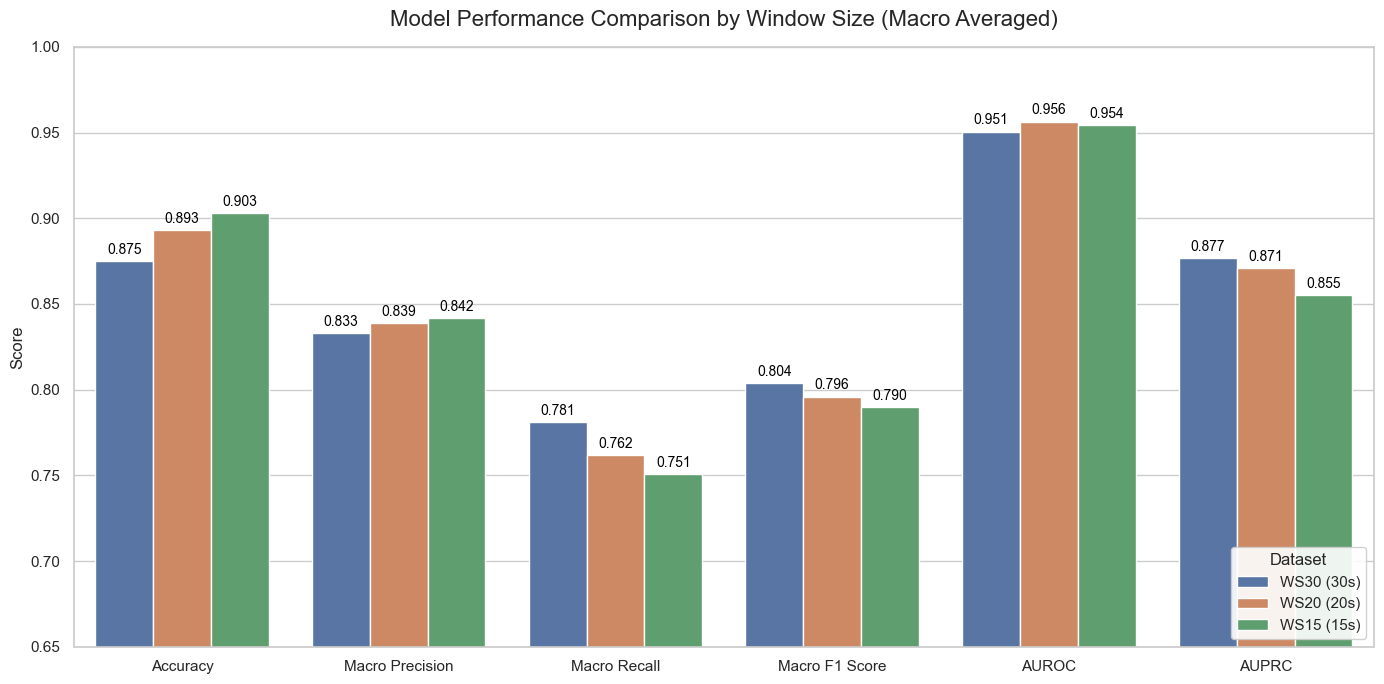

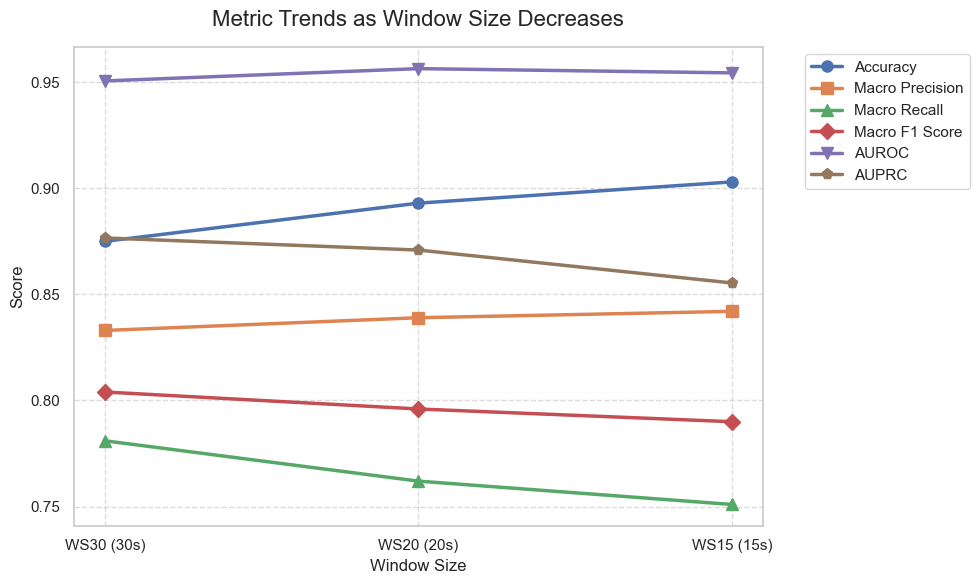

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_comparisons():
    # Extracted overall macro-averaged metrics from your logs
    data = {
        'Window Size': ['WS30 (30s)', 'WS20 (20s)', 'WS15 (15s)'],
        'Accuracy': [0.875, 0.893, 0.903],
        'Macro Precision': [0.833, 0.839, 0.842],
        'Macro Recall': [0.781, 0.762, 0.751],
        'Macro F1 Score': [0.804, 0.796, 0.790],
        'AUROC': [0.9506, 0.9564, 0.9544],
        'AUPRC': [0.8766, 0.8709, 0.8554]
    }

    df = pd.DataFrame(data)
    df_melted = df.melt(id_vars='Window Size', var_name='Metric', value_name='Score')

    # Set up styling
    sns.set_theme(style="whitegrid")
    colors = ['#4C72B0', '#DD8452', '#55A868'] # Blue, Orange, Green

    # ─────────────────────────────────────────────────────────────────────────────
    # Plot 1: Grouped Bar Chart
    # ─────────────────────────────────────────────────────────────────────────────
    plt.figure(figsize=(14, 7))
    ax = sns.barplot(data=df_melted, x='Metric', y='Score', hue='Window Size', palette=colors)
    
    plt.title('Model Performance Comparison by Window Size (Macro Averaged)', fontsize=16, pad=15)
    plt.ylabel('Score', fontsize=12)
    plt.xlabel('')
    
    # Set Y-axis to start at 0.65 to emphasize the differences
    plt.ylim(0.65, 1.0)

    # Add numeric labels on top of bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    fontsize=10, color='black', xytext=(0, 8), 
                    textcoords='offset points')

    plt.legend(title='Dataset', loc='lower right', framealpha=0.9)
    plt.tight_layout()
    plt.show()

    # ─────────────────────────────────────────────────────────────────────────────
    # Plot 2: Trend Line Plot
    # ─────────────────────────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 6))
    markers = ['o', 's', '^', 'D', 'v', 'p']

    for i, metric in enumerate(df.columns[1:]):
        plt.plot(df['Window Size'], df[metric], marker=markers[i], 
                 linewidth=2.5, markersize=8, label=metric)

    plt.title('Metric Trends as Window Size Decreases', fontsize=16, pad=15)
    plt.ylabel('Score', fontsize=12)
    plt.xlabel('Window Size', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Put legend outside the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_comparisons()